In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/robaabuamara/e-commerce/ecommerce_cleaned.csv


# E-Commerce Exploratory Data Analysis

This project explores a cleaned e-commerce dataset containing more than 138,000 records to identify patterns in sales, customer behavior, profitability, delivery performance, returns, customer satisfaction, and marketing activity.

In [2]:
import pandas as pd 
import numpy as np
df=pd.read_csv("/kaggle/input/datasets/robaabuamara/e-commerce/ecommerce_cleaned.csv")
df.head()
               

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,gross_sales_normalized,customer_age_scaled,customer_lifetime_value_scaled
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,945.40,588.33,345.04,36.50,12459.68,True,11,18.844116,0.660714,0.411201
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,2018.41,2031.88,-22.47,-1.11,13032.48,True,11,23.909313,0.142857,0.430139
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,468.35,257.73,197.57,42.18,6159.44,True,6,14.235910,0.910714,0.202900
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,546.52,277.84,247.83,45.35,5638.30,True,7,14.414011,0.839286,0.185670
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,2785.27,1231.88,1530.36,54.94,13240.10,True,8,22.370200,0.285714,0.437003


In [3]:
df.shape

(138116, 49)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 49 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        138116 non-null  object 
 1   order_date                      138116 non-null  object 
 2   order_time                      138116 non-null  object 
 3   order_status                    138116 non-null  object 
 4   sales_channel                   138116 non-null  object 
 5   customer_id                     138116 non-null  object 
 6   customer_name                   138116 non-null  object 
 7   customer_age                    138116 non-null  int64  
 8   gender                          138116 non-null  object 
 9   customer_segment                138116 non-null  object 
 10  customer_type                   138116 non-null  object 
 11  customer_city                   138116 non-null  object 
 12  customer_state  

In [5]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%Y-%m-%d'
)

In [6]:
df['order_date'].dtype

dtype('<M8[ns]')

In [7]:
print("Earliest order date:", df['order_date'].min())
print("Latest order date:", df['order_date'].max())

Earliest order date: 2021-01-01 00:00:00
Latest order date: 2025-12-31 00:00:00


In [8]:
df['order_year'] = df['order_date'].dt.year

In [9]:
df['order_year'].value_counts().sort_index()

order_year
2021    27554
2022    27564
2023    27632
2024    27768
2025    27598
Name: count, dtype: int64

In [10]:
yearly_sales = df.groupby('order_year')['net_sales'].sum()

yearly_sales

order_year
2021    35722650.67
2022    35327882.62
2023    35528143.74
2024    35466452.28
2025    35089134.43
Name: net_sales, dtype: float64

In [11]:
df['order_month'] = df['order_date'].dt.month

In [12]:
monthly_sales = df.groupby('order_month')['net_sales'].sum()

monthly_sales

order_month
1     12238598.83
2     10108027.56
3     13679516.86
4     12654092.89
5     12626730.13
6     13470903.94
7     14054324.07
8     15058347.23
9     13814730.98
10    14606076.52
11    21524457.18
12    23298457.55
Name: net_sales, dtype: float64

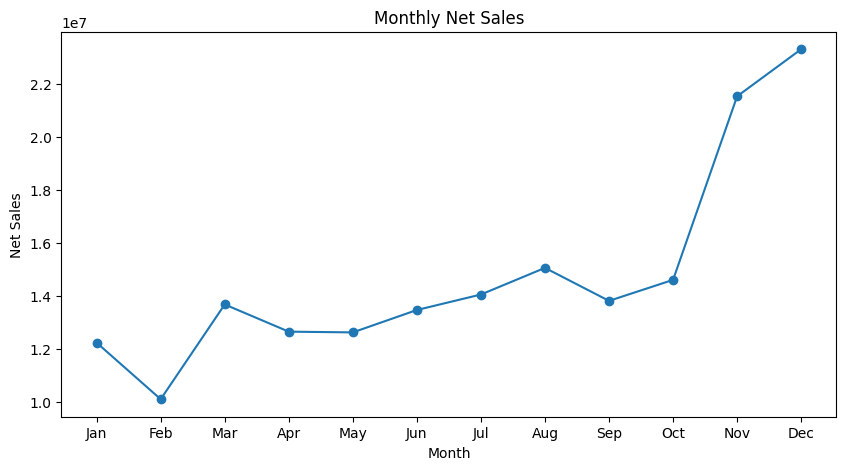

In [13]:
import matplotlib.pyplot as plt
month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(10, 5))

plt.plot(month_names, monthly_sales.values, marker='o')

plt.title('Monthly Net Sales')
plt.xlabel('Month')
plt.ylabel('Net Sales')

plt.show()

In [14]:
year_month_sales = (
    df.groupby(['order_year', 'order_month'])['net_sales']
      .sum()
      .unstack()
)

year_month_sales

order_month,1,2,3,4,5,6,7,8,9,10,11,12
order_year,,,,,,,,,,,,
2021,2374415.22,1905413.15,2753256.18,2469384.78,2546555.37,2710208.64,2894416.72,3220659.48,2720931.59,2991778.76,4234660.71,4900970.07
2022,2442770.60,2029412.22,2682800.73,2516740.73,2529145.45,2697622.96,2765292.19,2947796.56,2750776.22,2925151.89,4405731.78,4634641.29
2023,2467972.04,2035382.66,2700460.99,2495710.76,2555496.97,2801712.97,2715818.33,3070356.42,2747363.20,3001350.13,4261793.39,4674725.88
2024,2510721.37,2119755.19,2752681.57,2635743.36,2579097.07,2639763.54,2833868.86,2860775.42,2754826.02,2894022.77,4352110.30,4533086.81
2025,2442719.60,2018064.34,2790317.39,2536513.26,2416435.27,2621595.83,2844927.97,2958759.35,2840833.95,2793772.97,4270161.00,4555033.50


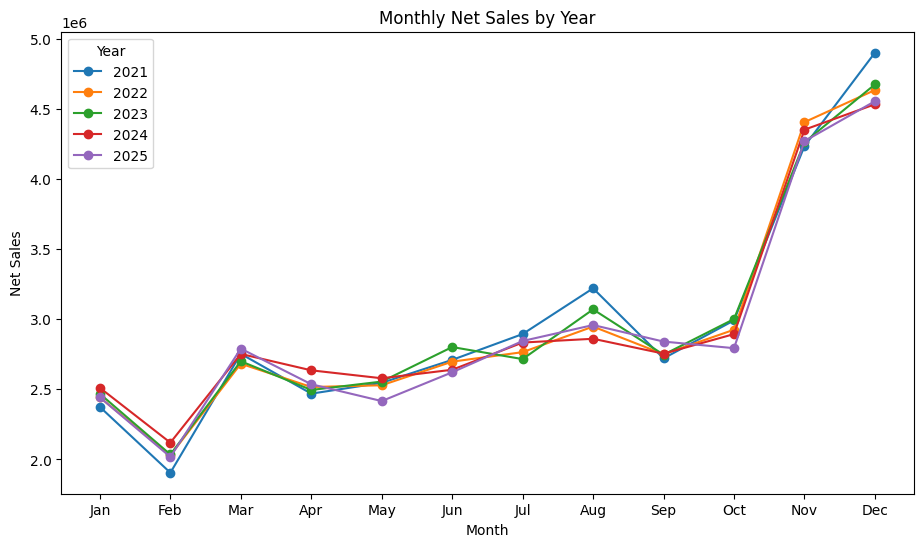

In [15]:
plt.figure(figsize=(11, 6))

for year in year_month_sales.index:
    plt.plot(
        month_names,
        year_month_sales.loc[year],
        marker='o',
        label=str(year)
    )

plt.title('Monthly Net Sales by Year')
plt.xlabel('Month')
plt.ylabel('Net Sales')
plt.legend(title='Year')
plt.show()

## Time & Seasonality Analysis
### Insight

Annual net sales remained relatively stable from 2021 to 2025.

However, a clear seasonal pattern appears within each year. Sales increase significantly in November and December across all five years, while February tends to record lower sales.

This suggests that the business experiences recurring end-of-year seasonality.

In [16]:
channel_sales = df.groupby('sales_channel')['net_sales'].sum().sort_values(ascending=False)

channel_sales

sales_channel
Mobile App      70834782.53
Website         61854736.08
Marketplace     26696190.22
Social Media    17748554.91
Name: net_sales, dtype: float64

In [17]:
channel_orders = df['sales_channel'].value_counts()

channel_orders

sales_channel
Mobile App      55318
Website         48237
Marketplace     20698
Social Media    13863
Name: count, dtype: int64

In [18]:
average_sales_per_order = (
    df.groupby('sales_channel')['net_sales']
      .mean()
      .sort_values(ascending=False)
)

average_sales_per_order

sales_channel
Marketplace     1289.795643
Website         1282.308935
Mobile App      1280.501510
Social Media    1280.282400
Name: net_sales, dtype: float64

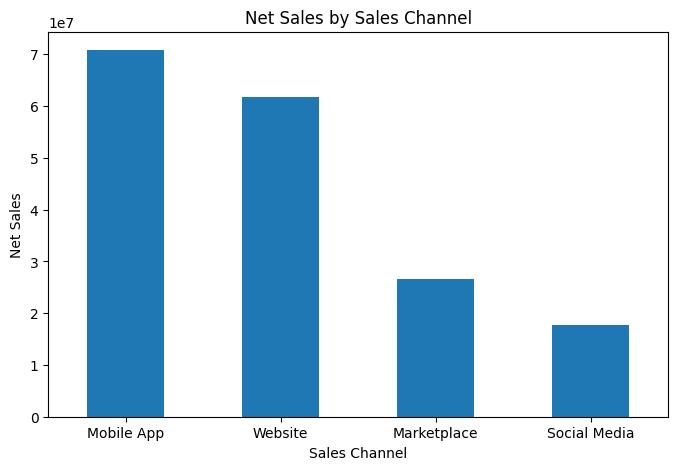

In [19]:
plt.figure(figsize=(8, 5))

channel_sales.plot(kind='bar')

plt.title('Net Sales by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Net Sales')
plt.xticks(rotation=0)

plt.show()

## Sales Channel Analysis
### Insight

Mobile App and Website generated the highest total net sales.

However, the average sales per order were very similar across all sales channels. This indicates that the higher total sales of Mobile App and Website were mainly driven by a larger number of orders rather than higher-value individual orders.

### Insight

Mobile App and Website generated the highest total net sales.

However, the average sales per order were very similar across all sales channels. This indicates that the higher total sales of Mobile App and Website were mainly driven by a larger number of orders rather than higher-value individual orders.

In [20]:
segment_sales = (
    df.groupby('customer_segment')['net_sales']
      .sum()
      .sort_values(ascending=False)
)

segment_sales

customer_segment
Consumer    97201007.90
Premium     44269794.13
VIP         17903164.81
Business    17760296.90
Name: net_sales, dtype: float64

In [21]:
segment_orders = df['customer_segment'].value_counts()

segment_orders

customer_segment
Consumer    75636
Premium     34746
VIP         13957
Business    13777
Name: count, dtype: int64

In [22]:
segment_avg_sales = (
    df.groupby('customer_segment')['net_sales']
      .mean()
      .sort_values(ascending=False)
)

segment_avg_sales

customer_segment
Business    1289.126581
Consumer    1285.115658
VIP         1282.737322
Premium     1274.097569
Name: net_sales, dtype: float64

## Customer Segment & Profitability Analysis
### Insight

The Consumer segment generated the highest total net sales.

However, the average sales per order were very similar across all customer segments. This suggests that the Consumer segment leads in total sales mainly because it has a much larger number of orders, rather than higher-value individual purchases.

In [23]:
segment_profit = (
    df.groupby('customer_segment')['profit']
      .sum()
      .sort_values(ascending=False)
)

segment_profit

customer_segment
Consumer    42819790.02
Premium     18177727.78
Business     7782525.28
VIP          7366352.68
Name: profit, dtype: float64

In [24]:
segment_profit_margin = (
    df.groupby('customer_segment')['profit_margin_percentage']
      .mean()
      .sort_values(ascending=False)
)

segment_profit_margin

customer_segment
Consumer    46.088015
Business    45.992864
Premium     43.224458
VIP         43.197068
Name: profit_margin_percentage, dtype: float64

In [25]:
df['is_repeat_customer'].value_counts()

is_repeat_customer
True     137782
False       334
Name: count, dtype: int64

In [26]:
df.groupby('is_repeat_customer')['customer_order_count'].describe()

,count,mean,std,min,25%,50%,75%,max
is_repeat_customer,,,,,,,,
False,334.0,1.00000,0.000000,1.0,1.0,1.0,1.0,1.0
True,137782.0,7.00508,2.429243,2.0,5.0,7.0,9.0,20.0


In [27]:
unique_customers = (
    df.groupby('is_repeat_customer')['customer_id']
      .nunique()
)

unique_customers

is_repeat_customer
False      334
True     24577
Name: customer_id, dtype: int64

In [28]:
customer_level = df.drop_duplicates(subset='customer_id')

customer_level.shape

(24911, 51)

In [29]:
customer_level.groupby('is_repeat_customer')['customer_lifetime_value'].mean()

is_repeat_customer
False    1303.762904
True     7808.774871
Name: customer_lifetime_value, dtype: float64

## Repeat Customer Analysis
### Insight

Repeat customers had a much higher average customer lifetime value than one-time customers.

The average customer lifetime value was approximately 7,809 for repeat customers compared with 1,304 for one-time customers.

However, the dataset contains far fewer one-time customers, so this comparison should be interpreted with caution.

In [30]:
country_sales = (
    df.groupby('customer_country')['net_sales']
      .sum()
      .sort_values(ascending=False)
)

country_sales

customer_country
USA          1.022301e+08
UK           2.796320e+07
Germany      1.604417e+07
Canada       9.198848e+06
Australia    8.813691e+06
India        7.718287e+06
UAE          5.165973e+06
Name: net_sales, dtype: float64

## Geographic Analysis
### Insight

The USA generated the highest total net sales by a substantial margin, followed by the UK and Germany.

This indicates that sales in the dataset are heavily concentrated in the US market.

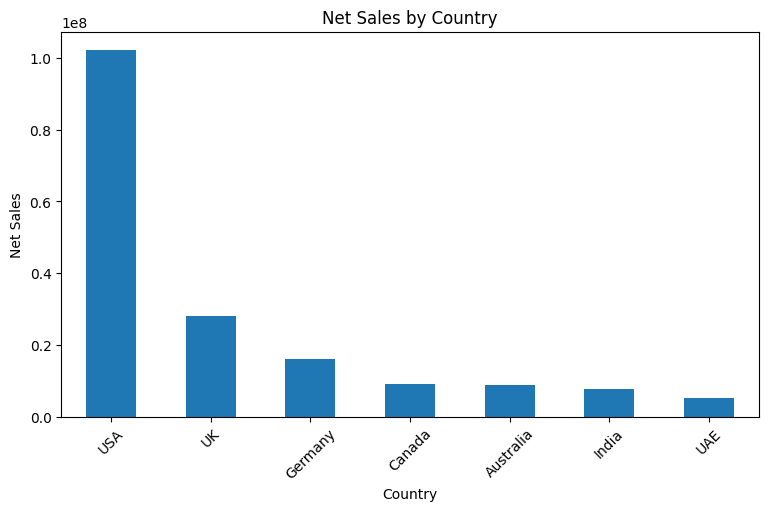

In [31]:
plt.figure(figsize=(9, 5))

country_sales.plot(kind='bar')

plt.title('Net Sales by Country')
plt.xlabel('Country')
plt.ylabel('Net Sales')
plt.xticks(rotation=45)

plt.show()

In [32]:
yearly_growth = yearly_sales.pct_change() * 100

yearly_growth

order_year
2021         NaN
2022   -1.105092
2023    0.566864
2024   -0.173641
2025   -1.063873
Name: net_sales, dtype: float64

## Time & Seasonality Analysis
### Year-over-Year Growth Analysis
### Insight

Year-over-year net sales remained highly stable from 2021 to 2025.

Annual changes stayed within approximately ±1.1%, indicating no major growth or decline across the five-year period.

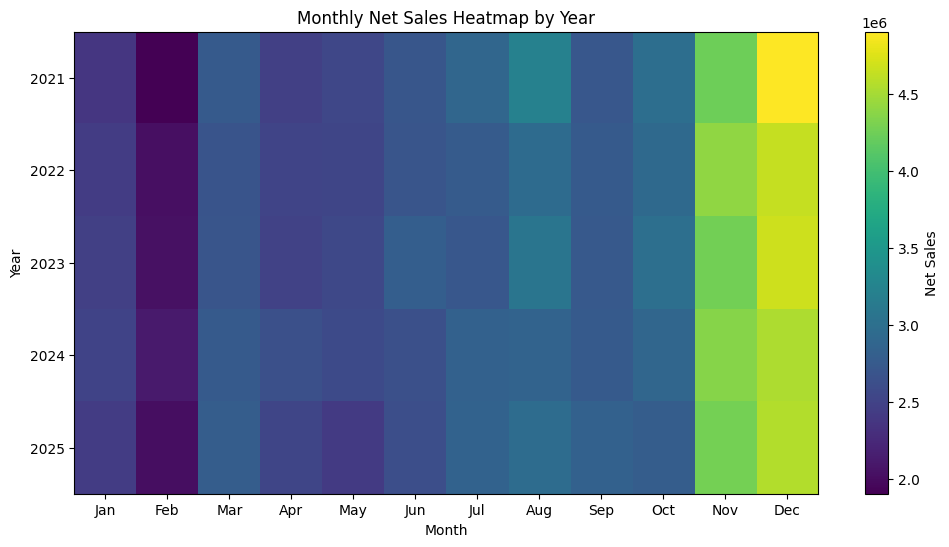

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.imshow(year_month_sales, aspect='auto')

plt.title('Monthly Net Sales Heatmap by Year')
plt.xlabel('Month')
plt.ylabel('Year')

plt.xticks(
    ticks=range(12),
    labels=month_names
)

plt.yticks(
    ticks=range(len(year_month_sales.index)),
    labels=year_month_sales.index
)

plt.colorbar(label='Net Sales')

plt.show()

## Time & Seasonality Analysis
### Monthly Sales Heatmap
### Insight

The heatmap confirms a recurring seasonal pattern across all five years.

November and December consistently show the highest net sales, while February tends to record the lowest sales. This pattern appears across multiple years rather than being driven by a single year.

In [34]:
payment_counts = df['payment_method'].value_counts()

payment_counts

payment_method
Credit Card          41460
Debit Card           27635
PayPal               20750
Digital Wallet       16382
Cash on Delivery     13863
Buy Now Pay Later    11061
Bank Transfer         6965
Name: count, dtype: int64

In [35]:
payment_sales = (
    df.groupby('payment_method')['net_sales']
      .sum()
      .sort_values(ascending=False)
)

payment_sales

payment_method
Credit Card          53389617.40
Debit Card           35355144.13
PayPal               26632143.06
Digital Wallet       20832787.20
Cash on Delivery     18025912.13
Buy Now Pay Later    13974727.03
Bank Transfer         8923932.79
Name: net_sales, dtype: float64

In [36]:
payment_avg_sales = (
    df.groupby('payment_method')['net_sales']
      .mean()
      .sort_values(ascending=False)
)

payment_avg_sales

payment_method
Cash on Delivery     1300.289413
Credit Card          1287.737998
PayPal               1283.476774
Bank Transfer        1281.253810
Debit Card           1279.361105
Digital Wallet       1271.687657
Buy Now Pay Later    1263.423473
Name: net_sales, dtype: float64

## Payment Methods Analysis
### Payment Method by Sales Channel
### Insight

Credit Card was the most frequently used payment method and generated the highest total net sales.

However, average order values were relatively similar across all payment methods. This suggests that Credit Card's higher total sales were mainly driven by a larger number of transactions rather than substantially higher-value orders.

In [37]:
payment_channel = pd.crosstab(
    df['sales_channel'],
    df['payment_method']
)

payment_channel

payment_method,Bank Transfer,Buy Now Pay Later,Cash on Delivery,Credit Card,Debit Card,Digital Wallet,PayPal
sales_channel,,,,,,,
Marketplace,1031,1608,2115,6246,4176,2472,3050
Mobile App,2849,4487,5460,16495,11142,6575,8310
Social Media,668,1090,1438,4151,2766,1645,2105
Website,2417,3876,4850,14568,9551,5690,7285


In [38]:
payment_channel_pct = pd.crosstab(
    df['sales_channel'],
    df['payment_method'],
    normalize='index'
) * 100

payment_channel_pct.round(2)

payment_method,Bank Transfer,Buy Now Pay Later,Cash on Delivery,Credit Card,Debit Card,Digital Wallet,PayPal
sales_channel,,,,,,,
Marketplace,4.98,7.77,10.22,30.18,20.18,11.94,14.74
Mobile App,5.15,8.11,9.87,29.82,20.14,11.89,15.02
Social Media,4.82,7.86,10.37,29.94,19.95,11.87,15.18
Website,5.01,8.04,10.05,30.20,19.80,11.80,15.10


## Payment Methods Analysis
### Insight

Payment method preferences were very similar across all sales channels.

Credit Card accounted for approximately 30% of transactions across every channel, followed by Debit Card at around 20% and PayPal at around 15%.

This suggests that payment behavior was relatively consistent regardless of the sales channel used.

In [39]:
return_counts = df['return_status'].value_counts()

return_counts

return_status
Not Returned    128654
Returned          9462
Name: count, dtype: int64

In [40]:
return_percentage = (
    df['return_status'].value_counts(normalize=True) * 100
)

return_percentage.round(2)

return_status
Not Returned    93.15
Returned         6.85
Name: proportion, dtype: float64

## Returns Analysis
### Insight

Approximately 6.85% of orders were returned, while 93.15% were not returned.

In [41]:
return_reasons = (
    df[df['return_status'] == 'Returned']['return_reason']
      .value_counts()
)

return_reasons

return_reason
Wrong Product              1237
Other                      1208
Changed Mind               1204
Size Issue                 1182
Defective Product          1174
Late Delivery              1172
Product Not as Expected    1147
Damaged Product            1138
Name: count, dtype: int64

## Returns Analysis
### Insight

Return reasons were distributed relatively evenly across the different categories.

"Wrong Product" was the most common return reason, but it accounted for only about 13% of returned orders. No single return reason clearly dominated the returns.

In [42]:
return_by_channel = pd.crosstab(
    df['sales_channel'],
    df['return_status'],
    normalize='index'
) * 100

return_by_channel.round(2)

return_status,Not Returned,Returned
sales_channel,,
Marketplace,93.07,6.93
Mobile App,93.09,6.91
Social Media,93.59,6.41
Website,93.13,6.87


## Returns Analysis
### Insight

Return rates were very similar across all sales channels, ranging from approximately 6.4% to 6.9%.

This suggests that no single sales channel had a substantially higher return rate than the others.

In [43]:
return_by_segment = pd.crosstab(
    df['customer_segment'],
    df['return_status'],
    normalize='index'
) * 100

return_by_segment.round(2)

return_status,Not Returned,Returned
customer_segment,,
Business,92.94,7.06
Consumer,93.16,6.84
Premium,93.15,6.85
VIP,93.31,6.69


## Returns Analysis
### Insight

Return rates were very similar across all customer segments, ranging from approximately 6.7% to 7.1%.

This suggests that return behavior was relatively consistent across customer segments, with no segment showing a substantially higher return rate.

In [44]:
df['delivery_days'].describe()

count    113559.000000
mean          4.557772
std           2.810012
min           0.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          14.000000
Name: delivery_days, dtype: float64

## Delivery Analysis
### Insight

Delivery typically took around 4 to 5 days.

The median delivery time was 4 days, while 75% of delivered orders arrived within 7 days. Delivery times ranged from same-day delivery to a maximum of 14 days.

In [45]:
df['delivery_delay'] = (
    df['delivery_days'] - df['estimated_delivery_days']
)

df['delivery_delay'].describe()

count    113559.000000
mean          0.258896
std           1.120265
min          -2.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: delivery_delay, dtype: float64

## Delivery Analysis
### Insight

Actual delivery times were generally very close to the estimated delivery times.

The median delivery delay was 0 days, and most delivered orders arrived exactly within the expected timeframe. Delivery differences ranged from 2 days early to 4 days late, with an average delay of only about 0.26 days.

In [46]:
delivery_status_summary = pd.cut(
    df['delivery_delay'],
    bins=[-float('inf'), -0.01, 0, float('inf')],
    labels=['Early', 'On Time', 'Late']
).value_counts()

delivery_status_summary

delivery_delay
On Time    87427
Late       16886
Early       9246
Name: count, dtype: int64


## Delivery Analysis
### Insight

Approximately 77% of delivered orders arrived exactly within the expected delivery timeframe.

Around 15% were delivered late, while about 8% arrived earlier than expected. Overall, delivery performance was relatively consistent with the estimated delivery times.

In [47]:
df['delivery_timing'] = pd.cut(
    df['delivery_delay'],
    bins=[-float('inf'), -0.01, 0, float('inf')],
    labels=['Early', 'On Time', 'Late']
)

In [48]:
df.groupby('delivery_timing', observed=True)['customer_rating'].mean()

delivery_timing
Early      4.017489
On Time    3.728394
Late       3.224571
Name: customer_rating, dtype: float64

## Delivery Analysis
### Insight

Customer ratings were noticeably higher for orders delivered early or on time.

Early deliveries had the highest average rating at approximately 4.02, while late deliveries had the lowest average rating at about 3.22.

This suggests that delivery performance is associated with customer satisfaction.

In [49]:
rating_counts = df['customer_rating'].value_counts().sort_index()

rating_counts

customer_rating
1.6       2
1.7       3
1.8       8
1.9      11
2.0      32
2.1      73
2.2     131
2.3     219
2.4     313
2.5     571
2.6     898
2.7    1288
2.8    1806
2.9    2527
3.0    3407
3.1    4476
3.2    5502
3.3    6618
3.4    7591
3.5    8755
3.6    9085
3.7    9362
3.8    9263
3.9    8744
4.0    7718
4.1    6628
4.2    5347
4.3    4177
4.4    3165
4.5    2197
4.6    1451
4.7     917
4.8     551
4.9     337
5.0     386
Name: count, dtype: int64

In [50]:
print("Average rating:", df['customer_rating'].mean())
print("Median rating:", df['customer_rating'].median())

Average rating: 3.6770145915339163
Median rating: 3.7


## Ratings & Reviews Analysis
### Insight

Customer ratings were generally moderate to positive.

The average customer rating was approximately 3.68, while the median was 3.7. Most ratings were concentrated around the mid-to-high 3 range, indicating relatively consistent customer satisfaction.

In [51]:

sentiment_counts = df['review_sentiment'].value_counts()

sentiment_counts

review_sentiment
Positive    78083
Neutral     34684
Negative      792
Name: count, dtype: int64

## Ratings & Reviews Analysis
### Insight

Most customer reviews were positive.

Approximately 68.8% of reviews were positive, around 30.5% were neutral, and less than 1% were negative.

This indicates that review sentiment in the dataset is heavily skewed toward positive feedback.

In [52]:
sentiment_rating = (
    df.groupby('review_sentiment')['customer_rating']
      .mean()
      .sort_values(ascending=False)
)

sentiment_rating

review_sentiment
Positive    3.928862
Neutral     3.141991
Negative    2.277778
Name: customer_rating, dtype: float64

## Ratings & Reviews Analysis
### Insight

Review sentiment was strongly aligned with customer ratings.

Positive reviews had the highest average rating at approximately 3.93, followed by neutral reviews at 3.14, while negative reviews had the lowest average rating at about 2.28.

This indicates that the sentiment labels are consistent with the numerical customer ratings.

In [53]:
delivery_sentiment = pd.crosstab(
    df['delivery_timing'],
    df['review_sentiment'],
    normalize='index'
) * 100

delivery_sentiment.round(2)

review_sentiment,Negative,Neutral,Positive
delivery_timing,,,
Early,0.03,9.43,90.54
On Time,0.18,25.99,73.84
Late,3.77,65.68,30.55


## Ratings & Reviews Analysis
### Insight

Delivery timing showed a clear association with review sentiment.

Early deliveries received the highest proportion of positive reviews at approximately 90.5%, while late deliveries received only about 30.6% positive reviews.

Late deliveries were much more likely to receive neutral or negative feedback, suggesting that delivery performance is strongly associated with customer satisfaction.

In [54]:
df['coupon_code'].value_counts().head()

coupon_code
No Coupon    110502
SAVE39          731
SAVE49          727
SAVE40          719
SAVE12          716
Name: count, dtype: int64

In [55]:
df['used_coupon'] = df['coupon_code'] != 'No Coupon'

In [56]:
df['used_coupon'].value_counts(normalize=True) * 100

used_coupon
False    80.006661
True     19.993339
Name: proportion, dtype: float64

In [57]:
coupon_comparison = df.groupby('used_coupon')[
    ['net_sales', 'discount_amount', 'profit']
].mean()

coupon_comparison

,net_sales,discount_amount,profit
used_coupon,,,
False,1283.948363,238.071515,551.643613
True,1276.722015,235.821261,550.035243


## Marketing & Coupons Analysis
### Insight

Coupon usage did not show a substantial difference in average net sales, discount amount, or profit per order.

Orders with and without coupons had very similar average values, suggesting that coupon usage alone was not strongly associated with higher sales or lower profitability in this dataset.

In [58]:
monthly_coupon_usage = (
    df.groupby('order_month')['used_coupon']
      .mean() * 100
)

monthly_coupon_usage

order_month
1     20.117611
2     19.870437
3     20.412123
4     20.365613
5     19.984372
6     19.981618
7     20.143039
8     19.562334
9     20.239521
10    19.573476
11    20.017434
12    19.832641
Name: used_coupon, dtype: float64

## Marketing & Coupons Analysis
### Insight

Coupon usage remained relatively stable throughout the year at around 20% of orders per month.

There was no noticeable increase in coupon usage during November or December, suggesting that the end-of-year sales increase was not primarily driven by higher coupon usage.

In [59]:
df['campaign_name'].value_counts().head(10)

campaign_name
Unknown Campaign    83233
Default_Campaign    22989
Google_Search_Q1     2748
Google_Shopping      2746
Google_Display       2731
FB_Retargeting       2270
FB_Dynamic           2233
Friend_Invite        2232
Referral_Program     2198
FB_Prospecting       2161
Name: count, dtype: int64

In [60]:
df['has_known_campaign'] = df['campaign_name'] != 'Unknown Campaign'

monthly_campaign_usage = (
    df.groupby('order_month')['has_known_campaign']
      .mean() * 100
)

monthly_campaign_usage

order_month
1     39.162282
2     40.077239
3     39.918684
4     39.683794
5     40.046884
6     40.073529
7     39.600274
8     39.704907
9     39.944726
10    39.371438
11    39.792043
12    39.591279
Name: has_known_campaign, dtype: float64

## Marketing & Coupons Analysis
### Insight

The proportion of orders associated with a known campaign remained very stable throughout the year at approximately 39–40%.

There was no noticeable increase in known campaign activity during November or December. Therefore, the end-of-year sales increase does not appear to be explained simply by a higher share of orders linked to known campaigns.

However, because a large number of orders have an unknown campaign value, campaign-related conclusions should be interpreted with caution.

In [61]:
known_campaigns = df[df['campaign_name'] != 'Unknown Campaign']

campaign_performance = (
    known_campaigns.groupby('campaign_name')['net_sales']
    .agg(['count', 'mean'])
    .sort_values(by='mean', ascending=False)
)

campaign_performance

,count,mean
campaign_name,,
Affiliate_Partner,1339,1327.823719
FB_Prospecting,2161,1312.026613
Insta_Influencer,1822,1310.081789
Insta_Reels,1799,1296.480422
Promo_Email,1459,1293.282337
FB_Dynamic,2233,1290.780967
Google_Search_Q1,2748,1283.997464
Friend_Invite,2232,1283.836940
Referral_Program,2198,1282.967671


## Marketing & Coupons Analysis
### Insight

Among known campaigns, Affiliate_Partner had the highest average net sales per order, while Weekly_Newsletter had the lowest.

Average order values varied across campaigns, although the differences were relatively moderate.

These results show an association between campaign type and order value, but they do not prove that the campaign itself caused the difference.

In [62]:
country_sales_without_usa = country_sales.drop('USA')

country_sales_without_usa

customer_country
UK           27963200.79
Germany      16044171.91
Canada        9198848.48
Australia     8813690.51
India         7718287.28
UAE           5165973.41
Name: net_sales, dtype: float64

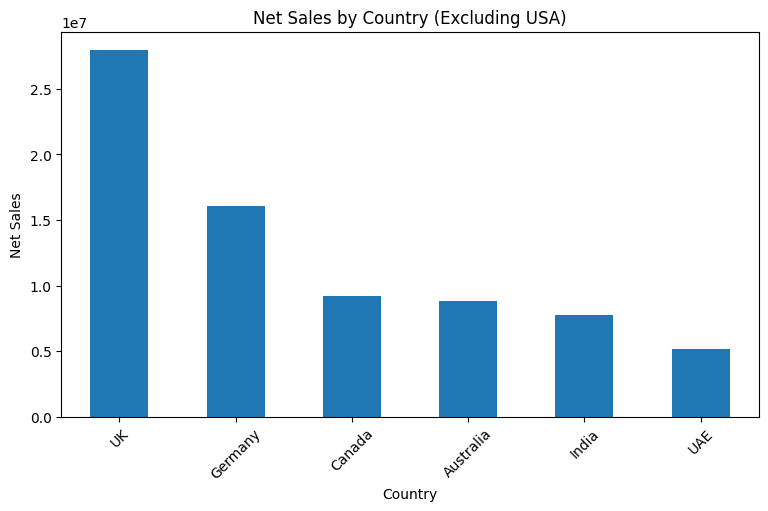

In [63]:
plt.figure(figsize=(9, 5))

country_sales_without_usa.plot(kind='bar')

plt.title('Net Sales by Country (Excluding USA)')
plt.xlabel('Country')
plt.ylabel('Net Sales')
plt.xticks(rotation=45)

plt.show()

## Geographic Analysis
### Insight

After excluding the USA, the UK remained the strongest market by net sales, followed by Germany.

Canada, Australia, and India showed comparatively closer sales levels, while the UAE had the lowest net sales among the remaining countries.

## Final Insights

- Annual net sales remained highly stable from 2021 to 2025, with year-over-year changes staying within approximately ±1.1%.

- A clear seasonal pattern was observed across all five years. November and December consistently recorded the highest net sales, while February tended to have the lowest sales.

- Mobile App and Website generated the highest total net sales. However, average order values were very similar across sales channels, showing that their higher sales were mainly driven by a larger number of orders.

- The Consumer segment generated the highest total sales and profit, largely because it had the highest number of orders. Average order values were very similar across customer segments.

- Repeat customers represented approximately 98.7% of unique customers in the dataset and had a much higher average Customer Lifetime Value than one-time customers.

- Credit Card was the most frequently used payment method and generated the highest total sales. However, average order values were relatively similar across payment methods.

- Approximately 6.85% of orders were returned. Return reasons were distributed relatively evenly, with no single reason strongly dominating the others.

- Return rates were also very similar across sales channels and customer segments.

- Delivery performance was generally close to expectations. Around 77% of delivered orders arrived on time, approximately 15% arrived late, and about 8% arrived early.

- Delivery timing showed a clear association with customer satisfaction. Early deliveries received higher average ratings and a much higher proportion of positive reviews, while late deliveries were associated with lower ratings and more neutral or negative feedback.

- Customer ratings averaged approximately 3.68 out of 5, with most reviews classified as positive.

- Coupon usage remained stable at around 20% of orders throughout the year. Orders with and without coupons showed very similar average net sales, discounts, and profit.

- Known campaign activity also remained stable throughout the year, suggesting that the November and December sales increase was not simply explained by a higher proportion of coupon or known-campaign orders.

- Among known campaigns, average order values varied moderately, with Affiliate_Partner showing the highest average net sales per order.

- The USA generated the highest total net sales by a large margin. After excluding the USA, the UK was the strongest remaining market, followed by Germany.

## Conclusion

This exploratory data analysis examined sales performance, seasonality, customer behavior, profitability, payment methods, returns, delivery performance, customer satisfaction, geographic markets, coupons, and marketing campaigns.

The analysis showed that overall annual sales were relatively stable, while strong end-of-year seasonality was consistently present. Higher total sales across channels and customer segments were generally driven by order volume rather than large differences in average order value.

Customer satisfaction was strongly associated with delivery performance, with early and on-time deliveries receiving better ratings and more positive reviews than late deliveries.

The analysis also showed that coupon usage and known campaign activity remained relatively stable throughout the year, meaning that the end-of-year sales increase cannot be explained simply by increased coupon or campaign activity.

Overall, this project demonstrates how cleaned e-commerce data can be explored using aggregation, comparison, visualization, and relationship analysis to identify meaningful business patterns and insights.

Some findings should be interpreted with caution. The dataset contains very few one-time customers compared with repeat customers, and a large proportion of campaign information was originally missing and labeled as "Unknown Campaign". In addition, the relationships identified in this EDA show associations rather than proving causation.